# ETF 动量 + R² 策略参数扫描回测

**策略逻辑：**
- 每隔 `rebal_period` 个交易日做一次调仓
- 调仓时，对每只 ETF 取过去 `n` 天的 log(收盘价)，做线性回归 log(P) = a + b·t
- 用 **斜率 b** 衡量动量强度，用 **R²** 衡量趋势质量
- 仅保留 R² ≥ 阈值的标的，从中选斜率最大的 top_k 只等权持有
- 若无标的通过筛选，该期空仓（收益为 0）

**扫描维度：** n (回看天数) × R² 阈值 × 调仓周期

In [23]:
import numpy as np
import pandas as pd
from pathlib import Path
from itertools import product
import warnings
warnings.filterwarnings('ignore')

DB_DIR = Path('db')

## 1. 加载数据

In [24]:
closes = {}
opens = {}
for fp in sorted(DB_DIR.glob('*.csv')):
    df = pd.read_csv(fp, index_col=0, parse_dates=True)
    if not df.empty and 'Close' in df.columns and len(df) >= 30:
        closes[fp.stem] = df['Close']
        if 'Open' in df.columns:
            opens[fp.stem] = df['Open']

# ffill 填充交易日间隙（ETF 上市前仍为 NaN，不会被错误填充）
panel = pd.DataFrame(closes).sort_index().ffill()
panel_open = pd.DataFrame(opens).sort_index().ffill()
print(f'加载 {panel.shape[1]} 只 ETF，{panel.shape[0]} 个交易日')
print(f'日期范围: {panel.index[0].strftime("%Y-%m-%d")} ~ {panel.index[-1].strftime("%Y-%m-%d")}')

加载 177 只 ETF，2963 个交易日
日期范围: 2014-01-02 ~ 2026-03-13


## 2. 回测引擎

利用滚动窗口向量化计算线性回归的斜率和 R²，避免逐只逐日循环。

In [25]:
def rolling_linreg(log_close: pd.DataFrame, n: int):
    """对 log(close) 面板做滚动 n 日线性回归，返回 (slope, R²) 两个面板。

    数学模型: y = a + b*x，其中
      x = [0, 1, 2, ..., n-1]   （时间序号，固定）
      y = log(close) 的滚动窗口  （每天、每只 ETF 各一个窗口）

    用最小二乘解析公式（非迭代）一次性计算全部日期×全部ETF的 slope(b) 和 R²。

    slope > 0 表示该 ETF 在过去 n 天呈上涨趋势，slope 越大涨势越强。
    R² 接近 1 表示趋势非常线性（稳定上涨），R² 低表示波动大、趋势不稳。
    """
    # ── 解析公式所需的 x 侧常量（与数据无关，只取决于窗口长度 n）──
    # Σx = 0+1+...+(n-1) = n(n-1)/2
    sum_x = n * (n - 1) / 2
    # Σx² = 0²+1²+...+(n-1)² = n(n-1)(2n-1)/6
    sum_x2 = n * (n - 1) * (2 * n - 1) / 6
    # 分母 = n*Σx² - (Σx)²
    denom_x = n * sum_x2 - sum_x ** 2

    # x 权重向量 [0, 1, 2, ..., n-1]，用于计算 Σ(x*y)
    weights = np.arange(n, dtype=float)

    # ── 滚动计算 y 侧统计量（向量化，对全部 ETF 列同时计算）──
    # Σy: 窗口内 log(close) 的求和
    roll_sum_y = log_close.rolling(n).sum()
    # Σy²: 窗口内 log(close)² 的求和
    roll_sum_y2 = (log_close ** 2).rolling(n).sum()
    # Σ(x*y): 窗口内 x[i]*y[i] 的求和，等价于 dot([0,1,...,n-1], window)
    roll_sum_xy = log_close.rolling(n).apply(lambda w: np.dot(weights, w), raw=True)

    # ── 最小二乘斜率 b = (n*Σxy - Σx*Σy) / (n*Σx² - (Σx)²) ──
    slope = (n * roll_sum_xy - sum_x * roll_sum_y) / denom_x

    # ── R² = SS_reg / SS_tot ──
    # SS_tot = n*Σy² - (Σy)²  （总离差平方和 × n，等比例不影响 R²）
    ss_tot = n * roll_sum_y2 - roll_sum_y ** 2
    # SS_reg = (n*Σxy - Σx*Σy)² / (n*Σx² - (Σx)²)  （回归平方和 × n）
    ss_reg = (n * roll_sum_xy - sum_x * roll_sum_y) ** 2 / denom_x
    # R² = SS_reg / SS_tot，SS_tot=0 时设为 NaN，最终 clip 到 [0,1]
    r2 = ss_reg / ss_tot.replace(0, np.nan)
    r2 = r2.clip(0, 1)

    return slope, r2


# ══════════════════════════════════════════════════════════════════════
# 交易成本参数
# ══════════════════════════════════════════════════════════════════════
SLIPPAGE = 0.001       # 滑点 0.1%: 买入价 = open*(1+0.001)，卖出价 = open*(1-0.001)
COMMISSION = 0.00006   # 单边手续费 0.006%（买一次扣一次，卖一次扣一次）

# ══════════════════════════════════════════════════════════════════════
# 预计算中间量（后续所有参数组合的回测复用，不重复计算）
# ══════════════════════════════════════════════════════════════════════
# log_close: 对收盘价取自然对数，用于线性回归（log空间下的线性=价格空间下的指数增长）
log_close = np.log(panel.replace(0, np.nan))
# daily_ret: 每日收益率 = (close[t] - close[t-1]) / close[t-1]
daily_ret = panel.pct_change()
# linreg_cache: {n: (slope_df, r2_df)}，对每个 n 只计算一次
linreg_cache = {}

def precompute_linreg(n_list):
    """对所有 n 值预计算 slope / R²，缓存到 linreg_cache。"""
    for n in n_list:
        if n not in linreg_cache:
            linreg_cache[n] = rolling_linreg(log_close, n)
            print(f'  预计算 rolling_linreg(n={n}) 完成')


# ══════════════════════════════════════════════════════════════════════
# 核心回测函数
# ══════════════════════════════════════════════════════════════════════
def backtest_momentum(
    slope: pd.DataFrame,
    r2: pd.DataFrame,
    daily_ret: pd.DataFrame,
    n: int,
    r2_threshold: float,
    rebal_period: int,
    top_k: int = 1,
    slippage: float = SLIPPAGE,
    commission: float = COMMISSION,
) -> pd.Series:
    """基于预计算的 slope/R² 运行回测，返回每日净值序列 (NAV)。

    ┌─────────────────────────────────────────────────────────────┐
    │ 实盘时序模型                                                  │
    │                                                             │
    │  T日(信号日)收盘后:                                           │
    │    用 close(T) 计算 slope、R²，选出下期应持有的 top_k 只标的     │
    │                                                             │
    │  T+1日(执行日)开盘:                                           │
    │    卖出旧持仓: 卖出价 = open(T+1) × (1 - slippage)            │
    │    买入新持仓: 买入价 = open(T+1) × (1 + slippage)            │
    │    每笔买/卖各扣 commission 手续费                              │
    │                                                             │
    │  T+1日收盘:                                                  │
    │    当天收益 = close(T+1) / 买入价 - 1                          │
    │                                                             │
    │  T+2 ~ 下次执行日前:                                          │
    │    每天收益 = close(t) / close(t-1) - 1  (close-to-close)     │
    └─────────────────────────────────────────────────────────────┘

    参数说明:
      slope, r2    : 预计算好的面板 (日期×ETF)
      daily_ret    : 每日收益率面板 (close-to-close)
      n            : 动量回看天数（线性回归窗口）
      r2_threshold : R² 过滤阈值，只选 R² >= 阈值的候选标的
      rebal_period : 调仓周期（交易日），每隔多少天重新选股
      top_k        : 每次持有多少只 ETF（等权分配）
      slippage     : 滑点（买卖各 0.1%）
      commission   : 单边手续费（买卖各 0.006%）

    返回:
      pd.Series，index=日期，values=每日净值（从 1.0 开始）
    """

    # ── 第一步：确定回测起始日 ──
    # 跳过前 n+5 天（前 n 天用于线性回归窗口，再留 5 天缓冲确保数据稳定）
    start_idx = n + 5
    dates = daily_ret.index[start_idx:]

    # ── 第二步：在每个"信号日"计算选股结果 ──
    # rebal_indices: [0, rebal_period, 2*rebal_period, ...]
    # 即 dates 数组中第 0、rebal_period、2*rebal_period... 天为信号日
    rebal_indices = list(range(0, len(dates), rebal_period))

    # signal_map: {dates数组中的位置索引 -> 选出的ETF代码列表}
    signal_map = {}
    for idx_pos in rebal_indices:
        date = dates[idx_pos]

        # 取当天所有 ETF 的 slope 和 R²，去掉 NaN
        s = slope.loc[date].dropna()
        r = r2.loc[date].dropna()

        # 只保留 slope 和 R² 都有值的 ETF
        common = s.index.intersection(r.index)
        s, r = s[common], r[common]

        # 筛选: R² >= 阈值，按 slope 降序排列（动量最强的排前面）
        candidates = s[r >= r2_threshold].sort_values(ascending=False)

        # 取前 top_k 只；如果没有任何候选则空仓 []
        selected = candidates.head(top_k).index.tolist() if len(candidates) >= 1 else []
        signal_map[idx_pos] = selected

    # ── 第三步：信号日→执行日映射 ──
    # 信号在 T 日收盘后产生，T+1 日执行
    # exec_map: {执行日在dates中的位置 -> 要切换到的持仓列表}
    exec_map = {}
    for sig_idx, selected in signal_map.items():
        exec_idx = sig_idx + 1          # T+1
        if exec_idx < len(dates):       # 最后一天的信号无法执行
            exec_map[exec_idx] = selected

    # ── 第四步：逐日模拟净值 ──
    #
    # 仓位模型（关键）:
    #   总资金分为 top_k 等份，每份权重 w = 1/top_k
    #   若实际选出 k 只标的（k <= top_k），则:
    #     - k 份投入标的，每只占 1/top_k
    #     - (top_k - k) 份为现金，收益率 = 0
    #   组合收益 = Σ(每只标的收益 × 1/top_k) + 现金部分×0
    #            = Σ(每只标的收益) / top_k    （不是除以 k !）
    #
    #   手续费同理：只对实际交易的仓位收费
    #     卖 k_sell 只: 手续费 = k_sell/top_k × commission
    #     买 k_buy 只:  手续费 = k_buy/top_k × commission

    cum = 1.0                           # 累计净值，从 1.0 开始
    nav_values = np.ones(len(dates))    # 存储每天的净值
    current_holdings = []               # 当前持有的 ETF 代码列表

    for d in range(len(dates)):
        date = dates[d]

        # ─── 场景A：今天是执行日（需要换仓）───
        if d in exec_map:
            new_holdings = exec_map[d]

            # 只有持仓真正发生变化时才执行交易（避免无意义的买卖摩擦）
            if sorted(new_holdings) != sorted(current_holdings):

                # ①【卖出旧持仓】
                # 每只旧持仓权重 = 1/top_k
                # 卖出价 = 今天的 open × (1 - slippage)
                # 该只的收益 = 卖出价 / 昨日close - 1
                # 对组合的贡献 = 收益 × (1/top_k)
                if current_holdings and d > 0:
                    prev_date = dates[d - 1]
                    k_sell = len(current_holdings)
                    sell_rets = []
                    for sym in current_holdings:
                        prev_cl = panel.loc[prev_date, sym]
                        op = panel_open.loc[date, sym] if (date in panel_open.index and sym in panel_open.columns) else panel.loc[date, sym]
                        sell_price = op * (1 - slippage)
                        sell_rets.append(sell_price / prev_cl - 1)
                    # 组合卖出收益 = Σ(各标的收益) / top_k
                    # 现金部分 (top_k - k_sell) 份收益为 0，自动体现在除以 top_k 中
                    portfolio_sell_ret = np.nansum(sell_rets) / top_k
                    cum *= (1 + portfolio_sell_ret)
                    # 手续费只对实际卖出的仓位收: k_sell/top_k × commission
                    cum *= (1 - k_sell / top_k * commission)

                # ②【买入新持仓】
                # 每只新持仓权重 = 1/top_k
                # 买入价 = 今天的 open × (1 + slippage)
                # 当天收益 = close / 买入价 - 1
                if new_holdings:
                    k_buy = len(new_holdings)
                    # 手续费只对实际买入的仓位收: k_buy/top_k × commission
                    cum *= (1 - k_buy / top_k * commission)
                    buy_rets = []
                    for sym in new_holdings:
                        op = panel_open.loc[date, sym] if (date in panel_open.index and sym in panel_open.columns) else panel.loc[date, sym]
                        buy_price = op * (1 + slippage)
                        cl = panel.loc[date, sym]
                        buy_rets.append(cl / buy_price - 1)
                    # 组合买入当天收益 = Σ(各标的收益) / top_k
                    portfolio_buy_ret = np.nansum(buy_rets) / top_k
                    cum *= (1 + portfolio_buy_ret)

                current_holdings = new_holdings

            else:
                # 持仓未变（新选出的标的和当前持仓完全一样），不交易
                # 按正常 close-to-close 计算当天收益
                if current_holdings:
                    # 组合收益 = Σ(各标的日收益) / top_k，而非 mean
                    rets = daily_ret.loc[date, current_holdings]
                    portfolio_ret = np.nansum(rets.values) / top_k
                    cum *= (1 + portfolio_ret)

        # ─── 场景B：今天是普通持仓日（不换仓）───
        else:
            if current_holdings:
                # 组合收益 = Σ(各标的日收益) / top_k
                # 若持仓 k < top_k，剩余 (top_k-k)/top_k 为现金，收益=0
                rets = daily_ret.loc[date, current_holdings]
                portfolio_ret = np.nansum(rets.values) / top_k
                cum *= (1 + portfolio_ret)

        # 记录当天净值
        nav_values[d] = cum

    return pd.Series(nav_values, index=dates, name='NAV')

## 3. 定义参数网格

In [26]:
N_LIST = [3, 5, 10, 15, 20, 25, 30, 40]      # 动量回看天数
R2_LIST = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]          # R² 阈值
REBAL_LIST = [5, 10, 15, 20, 30]                  # 调仓周期（交易日）
TOP_K_LIST = [1, 2, 3, 5]                        # 每次持有 ETF 数量（网格）

param_grid = list(product(N_LIST, R2_LIST, REBAL_LIST, TOP_K_LIST))
print(f'参数组合数: {len(param_grid)}')

参数组合数: 1120


## 4. 批量回测

In [27]:
import time as _time
import multiprocessing as _mp
from concurrent.futures import ProcessPoolExecutor as _PPE
import os as _os

# ══════════════════════════════════════════════════════════════════════
# 预计算所有 n 值的线性回归（最耗时步骤，每个 n 只算一次，多个参数组合复用）
# linreg_cache 结构: {n: (slope_df, r2_df)}
# slope_df / r2_df 形状: (交易日数 × ETF数)
# ══════════════════════════════════════════════════════════════════════
print('预计算 rolling linreg ...')
precompute_linreg(N_LIST)

# ══════════════════════════════════════════════════════════════════════
# 多进程并行回测
#
# 原理: 每个参数组合 (n, R2, rebal, top_k) 的回测完全独立，
# 使用 fork 模式创建子进程，子进程通过 copy-on-write 共享
# panel, panel_open, daily_ret, linreg_cache 等大型 DataFrame，
# 无需序列化传输，零额外内存开销。
# ══════════════════════════════════════════════════════════════════════
_NUM_WORKERS = max(1, _os.cpu_count() - 1)  # CPU核数-1，留1核给系统

def _bt_one(params):
    """单个参数组合的回测 + 绩效指标计算。

    在 worker 进程中执行，通过 fork 继承父进程的
    linreg_cache, daily_ret, panel, panel_open 等全局变量。
    """
    n, r2_thresh, rebal, top_k = params

    # 从缓存中取出该 n 值对应的 slope 和 R² 面板
    slope, r2 = linreg_cache[n]

    # 运行回测，得到逐日净值序列
    nav = backtest_momentum(slope, r2, daily_ret, n=n, r2_threshold=r2_thresh,
                            rebal_period=rebal, top_k=top_k)

    # 构造唯一标签，用于 nav_cache 索引
    label = f'n={n}_R2={r2_thresh}_rebal={rebal}_topk={top_k}'

    # ── 计算逐年收益率 ──
    years = sorted(nav.index.year.unique())
    annual_rets = {}
    for yr in years:
        yr_nav = nav[nav.index.year == yr]
        if len(yr_nav) < 10:       # 不足10个交易日的年份跳过（如数据起始/结束年）
            continue
        # 该年收益 = 年末净值 / 年初净值 - 1
        annual_rets[yr] = yr_nav.iloc[-1] / yr_nav.iloc[0] - 1

    # "完整年"= 排除首尾不完整的年份（数据起始年和当前年可能不足12个月）
    full_years = [y for y in annual_rets if y != years[0] and y != years[-1]]
    avg_ret = np.mean([annual_rets[y] for y in full_years]) if full_years else np.nan

    # ── 计算汇总指标 ──
    # 总收益 = 最终净值 / 初始净值 - 1
    total_ret = nav.iloc[-1] / nav.iloc[0] - 1
    # 回测跨越的年数（用于年化）
    n_years = (nav.index[-1] - nav.index[0]).days / 365.25
    # 年化收益 = (1 + total_ret)^(1/n_years) - 1
    annualized = (1 + total_ret) ** (1 / n_years) - 1 if n_years > 0 else np.nan
    # 最大回撤 = max(1 - NAV[t] / NAV历史最高)，取负值
    max_dd = ((nav / nav.cummax()) - 1).min()
    # 年化 Sharpe（日收益均值/标准差 × sqrt(252)，无风险利率=0）
    dr = nav.pct_change().dropna()
    sharpe = (dr.mean() / dr.std() * np.sqrt(252)) if dr.std() > 0 else np.nan

    row = {'n': n, 'R2_threshold': r2_thresh, 'rebal_period': rebal, 'top_k': top_k}
    row.update(annual_rets)     # 每年收益率也存入，如 {2014: 0.12, 2015: -0.05, ...}
    row['avg_full_year'] = avg_ret
    row['annualized'] = annualized
    row['total_ret'] = total_ret
    row['sharpe'] = sharpe
    row['max_drawdown'] = max_dd
    return label, nav, row

# ─── 12 年全量回测 ───
print(f'使用 {_NUM_WORKERS} 个进程并行回测 {len(param_grid)} 组参数（12年全量）...')
t0 = _time.time()
_ctx = _mp.get_context('fork')
with _PPE(max_workers=_NUM_WORKERS, mp_context=_ctx) as executor:
    _all_results = list(executor.map(_bt_one, param_grid, chunksize=20))

results_12y = []
nav_cache = {}
for label, nav, row in _all_results:
    nav_cache[label] = nav
    results_12y.append(row)
elapsed_12y = _time.time() - t0
print(f'12年回测完成，共 {len(results_12y)} 组参数，耗时 {elapsed_12y:.1f}s')

# ─── 近 3 年数据与预计算 ───
panel_3y = panel.loc[panel.index >= panel.index[-1] - pd.DateOffset(years=3)]
panel_open_3y = panel_open.reindex(panel_3y.index).ffill().bfill()
log_close_3y = np.log(panel_3y.replace(0, np.nan))
daily_ret_3y = panel_3y.pct_change()
linreg_cache_3y = {}
for n in N_LIST:
    linreg_cache_3y[n] = rolling_linreg(log_close_3y, n)
print('近3年 rolling_linreg 预计算完成')

def _bt_one_3y(params):
    """单组参数的 3 年回测，返回 (label, nav_3y, row_3y)。"""
    n, r2_thresh, rebal, top_k = params
    slope_3y, r2_3y = linreg_cache_3y[n]
    nav = backtest_momentum(slope_3y, r2_3y, daily_ret_3y, n=n, r2_threshold=r2_thresh,
                            rebal_period=rebal, top_k=top_k)
    label = f'n={n}_R2={r2_thresh}_rebal={rebal}_topk={top_k}'
    years = sorted(nav.index.year.unique())
    annual_rets = {}
    for yr in years:
        yr_nav = nav[nav.index.year == yr]
        if len(yr_nav) < 10:
            continue
        annual_rets[yr] = yr_nav.iloc[-1] / yr_nav.iloc[0] - 1
    full_years = [y for y in annual_rets if y != years[0] and y != years[-1]]
    avg_ret = np.mean([annual_rets[y] for y in full_years]) if full_years else np.nan
    total_ret = nav.iloc[-1] / nav.iloc[0] - 1
    n_years = (nav.index[-1] - nav.index[0]).days / 365.25
    annualized = (1 + total_ret) ** (1 / n_years) - 1 if n_years > 0 else np.nan
    max_dd = ((nav / nav.cummax()) - 1).min()
    dr = nav.pct_change().dropna()
    sharpe = (dr.mean() / dr.std() * np.sqrt(252)) if dr.std() > 0 else np.nan
    row = {'n': n, 'R2_threshold': r2_thresh, 'rebal_period': rebal, 'top_k': top_k}
    row.update(annual_rets)
    row['avg_full_year'] = avg_ret
    row['annualized'] = annualized
    row['total_ret'] = total_ret
    row['sharpe'] = sharpe
    row['max_drawdown'] = max_dd
    return label, nav, row

# ─── 3 年回测 ───
print(f'使用 {_NUM_WORKERS} 个进程并行回测 {len(param_grid)} 组参数（近3年）...')
t0 = _time.time()
with _PPE(max_workers=_NUM_WORKERS, mp_context=_ctx) as executor:
    _all_3y = list(executor.map(_bt_one_3y, param_grid, chunksize=20))

results_3y = []
nav_cache_3y = {}
for label, nav, row in _all_3y:
    nav_cache_3y[label] = nav
    results_3y.append(row)
elapsed_3y = _time.time() - t0
print(f'近3年回测完成，共 {len(results_3y)} 组参数，耗时 {elapsed_3y:.1f}s')

# ─── 合并为同一表格：每行一个参数组合，含 12 年与 3 年指标 ───
def _merge_row(r12, r3):
    """合并 12y 与 3y 的 row，键带后缀避免冲突。"""
    year_cols_12y = [c for c in r12 if isinstance(c, (int, np.integer))]
    out = {'n': r12['n'], 'R2_threshold': r12['R2_threshold'], 'rebal_period': r12['rebal_period'], 'top_k': r12['top_k']}
    for c in year_cols_12y:
        out[c] = r12[c]
    out['avg_full_year_12y'] = r12['avg_full_year']
    out['annualized_12y'] = r12['annualized']
    out['total_ret_12y'] = r12['total_ret']
    out['sharpe_12y'] = r12['sharpe']
    out['max_drawdown_12y'] = r12['max_drawdown']
    year_cols_3y = [c for c in r3 if isinstance(c, (int, np.integer))]
    for c in year_cols_3y:
        out[f'y{c}_3y'] = r3[c]
    out['annualized_3y'] = r3['annualized']
    out['total_ret_3y'] = r3['total_ret']
    out['sharpe_3y'] = r3['sharpe']
    out['max_drawdown_3y'] = r3['max_drawdown']
    return out

results = [_merge_row(r12, r3) for r12, r3 in zip(results_12y, results_3y)]
print(f'\n合并完成，共 {len(results)} 组参数（12年+3年同表）')

预计算 rolling linreg ...
  预计算 rolling_linreg(n=3) 完成
  预计算 rolling_linreg(n=5) 完成
  预计算 rolling_linreg(n=10) 完成
  预计算 rolling_linreg(n=15) 完成
  预计算 rolling_linreg(n=20) 完成
  预计算 rolling_linreg(n=25) 完成
  预计算 rolling_linreg(n=30) 完成
  预计算 rolling_linreg(n=40) 完成
使用 9 个进程并行回测 1120 组参数（12年全量）...
12年回测完成，共 1120 组参数，耗时 46.6s
近3年 rolling_linreg 预计算完成
使用 9 个进程并行回测 1120 组参数（近3年）...
近3年回测完成，共 1120 组参数，耗时 11.7s

合并完成，共 1120 组参数（12年+3年同表）


## 5. 结果总览

In [29]:
result_df = pd.DataFrame(results)
result_df.to_csv('backtest_result.csv', index=False, encoding='utf-8-sig')
print(f'已导出 backtest_result.csv（共 {len(result_df)} 条，含 12 年 + 3 年指标）')

year_cols = [c for c in result_df.columns if isinstance(c, (int, np.integer))]
fmt_cols = year_cols + ['avg_full_year_12y', 'annualized_12y', 'total_ret_12y', 'sharpe_12y', 'max_drawdown_12y',
                        'annualized_3y', 'total_ret_3y', 'sharpe_3y', 'max_drawdown_3y']
fmt_cols = [c for c in fmt_cols if c in result_df.columns]

display_df = result_df.copy()
for c in fmt_cols:
    if c in display_df.columns:
        display_df[c] = display_df[c].map(lambda x: f'{x:.2%}' if pd.notna(x) and 'sharpe' not in str(c) else (f'{x:.2f}' if pd.notna(x) and 'sharpe' in str(c) else '-'))

display_df = display_df.sort_values('annualized_12y', ascending=False, key=lambda s: result_df['annualized_12y'])

print('所有参数组合回测结果（按 12 年年化收益排序）:')
display(display_df.head(30))

已导出 backtest_result.csv（共 1120 条，含 12 年 + 3 年指标）
所有参数组合回测结果（按 12 年年化收益排序）:


,n,R2_threshold,rebal_period,top_k,2014,2015,2016,2017,2018,2019,...,sharpe_12y,max_drawdown_12y,y2023_3y,y2024_3y,y2025_3y,y2026_3y,annualized_3y,total_ret_3y,sharpe_3y,max_drawdown_3y
856,30,0.3,30,1,398.88%,-38.08%,-25.96%,39.48%,-37.72%,26.91%,...,0.80,-78.37%,-0.096303,-0.370307,-0.027039,-0.104320,-20.88%,-48.77%,-0.43,-67.77%
176,5,0.4,30,1,139.78%,-3.12%,7.52%,36.95%,-21.91%,42.17%,...,0.90,-69.82%,0.089771,-0.301386,-0.155715,0.193425,-7.30%,-20.11%,-0.05,-56.53%
196,5,0.5,30,1,155.42%,-15.67%,4.56%,24.00%,-18.79%,40.85%,...,0.91,-69.82%,0.089771,-0.312852,-0.155715,0.193425,-7.82%,-21.42%,-0.06,-57.24%
156,5,0.3,30,1,136.94%,-3.12%,21.68%,18.77%,-20.40%,42.17%,...,0.90,-69.82%,0.089771,-0.301386,0.308359,0.193425,7.47%,23.80%,0.39,-53.59%
388,10,0.8,15,1,162.51%,37.52%,8.02%,50.54%,-12.23%,27.04%,...,0.92,-43.39%,-0.222061,-0.173931,0.004941,0.028892,-12.40%,-32.26%,-0.26,-50.36%
916,30,0.6,30,1,194.48%,-10.79%,-14.64%,30.88%,-18.11%,-7.97%,...,0.80,-60.81%,-0.083525,-0.108896,-0.027039,-0.104320,-10.21%,-26.48%,-0.12,-53.75%
896,30,0.5,30,1,168.78%,-18.47%,-14.64%,39.48%,-21.83%,-3.07%,...,0.78,-61.46%,-0.083525,-0.112185,-0.027039,-0.104320,-10.33%,-26.75%,-0.12,-53.92%
876,30,0.4,30,1,218.48%,-38.08%,-25.96%,39.48%,-27.24%,26.16%,...,0.74,-74.88%,-0.083525,-0.021059,-0.027039,-0.104320,-7.21%,-19.23%,-0.02,-50.51%
216,5,0.6,30,1,155.42%,-15.67%,2.12%,8.28%,-6.66%,36.82%,...,0.85,-69.82%,0.290310,-0.184180,-0.192583,0.193425,1.87%,5.63%,0.23,-50.12%
56,3,0.5,30,1,130.31%,-46.68%,3.50%,3.02%,2.12%,46.44%,...,0.79,-78.74%,-0.240634,-0.366674,0.435735,0.193425,-4.57%,-12.99%,0.04,-61.39%


## 6. 按维度影响图（12年 vs 3年）

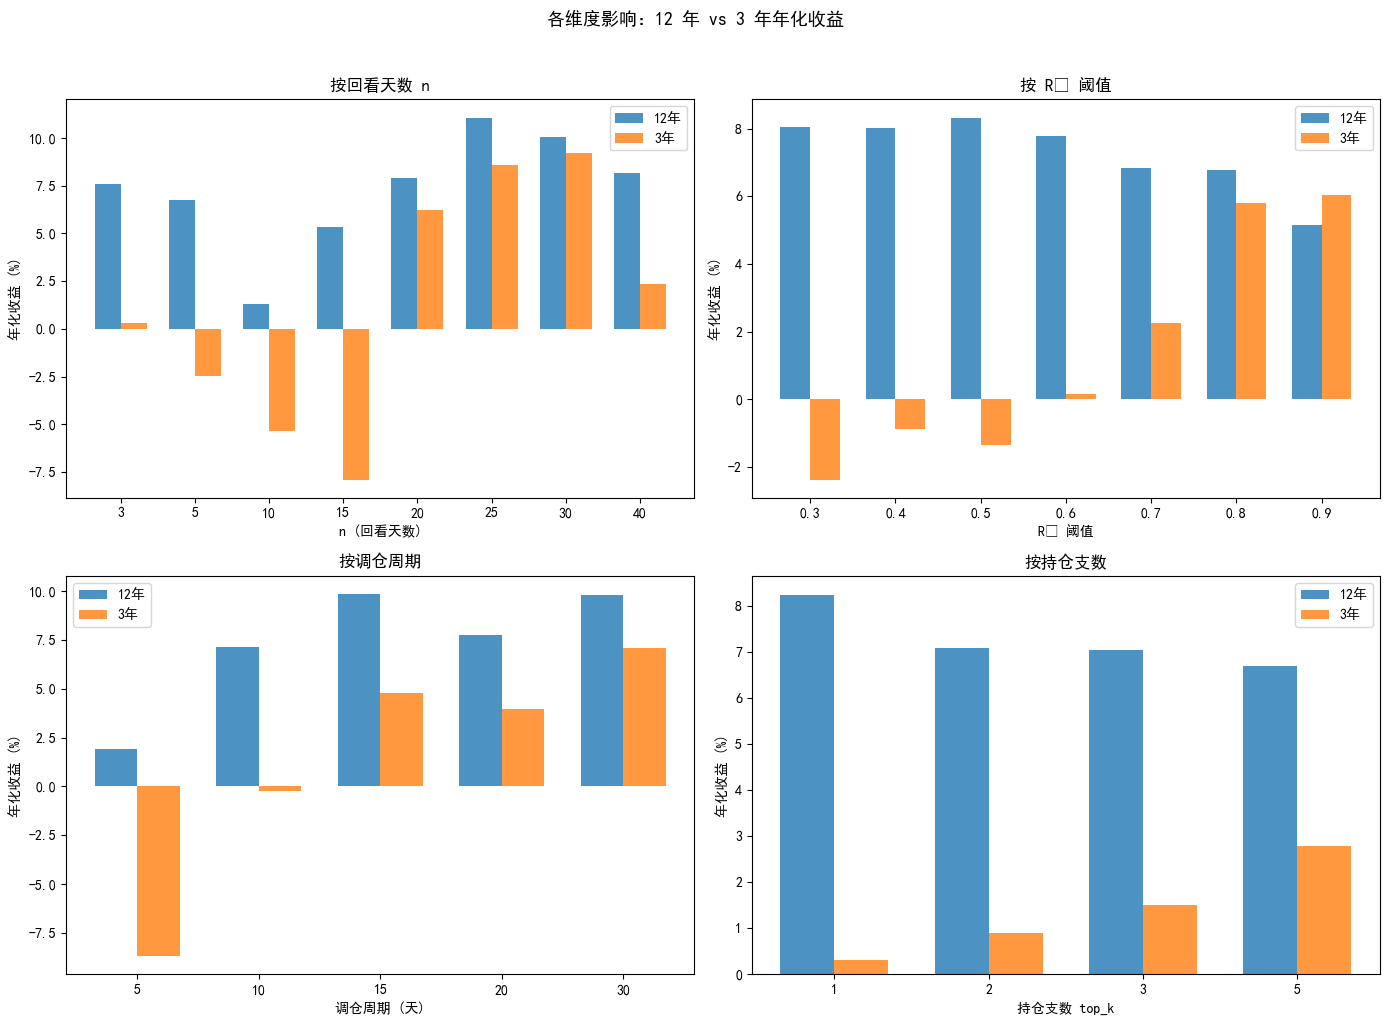

In [30]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

# 四个维度，每张图内 12 年 vs 3 年对比（年化收益均值）
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
w = 0.35

# 按 n
by_n_12 = result_df.groupby('n')['annualized_12y'].mean() * 100
by_n_3 = result_df.groupby('n')['annualized_3y'].mean() * 100
x = np.arange(len(by_n_12))
axes[0, 0].bar(x - w/2, by_n_12.values, w, label='12年', alpha=0.8)
axes[0, 0].bar(x + w/2, by_n_3.values, w, label='3年', alpha=0.8)
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(by_n_12.index.astype(str))
axes[0, 0].set_xlabel('n (回看天数)')
axes[0, 0].set_ylabel('年化收益 (%)')
axes[0, 0].set_title('按回看天数 n')
axes[0, 0].legend()

# 按 R²
by_r2_12 = result_df.groupby('R2_threshold')['annualized_12y'].mean() * 100
by_r2_3 = result_df.groupby('R2_threshold')['annualized_3y'].mean() * 100
x2 = np.arange(len(by_r2_12))
axes[0, 1].bar(x2 - w/2, by_r2_12.values, w, label='12年', alpha=0.8)
axes[0, 1].bar(x2 + w/2, by_r2_3.values, w, label='3年', alpha=0.8)
axes[0, 1].set_xticks(x2)
axes[0, 1].set_xticklabels([f'{v:.1f}' for v in by_r2_12.index])
axes[0, 1].set_xlabel('R² 阈值')
axes[0, 1].set_ylabel('年化收益 (%)')
axes[0, 1].set_title('按 R² 阈值')
axes[0, 1].legend()

# 按调仓周期
by_r_12 = result_df.groupby('rebal_period')['annualized_12y'].mean() * 100
by_r_3 = result_df.groupby('rebal_period')['annualized_3y'].mean() * 100
x3 = np.arange(len(by_r_12))
axes[1, 0].bar(x3 - w/2, by_r_12.values, w, label='12年', alpha=0.8)
axes[1, 0].bar(x3 + w/2, by_r_3.values, w, label='3年', alpha=0.8)
axes[1, 0].set_xticks(x3)
axes[1, 0].set_xticklabels(by_r_12.index.astype(str))
axes[1, 0].set_xlabel('调仓周期 (天)')
axes[1, 0].set_ylabel('年化收益 (%)')
axes[1, 0].set_title('按调仓周期')
axes[1, 0].legend()

# 按 top_k
by_k_12 = result_df.groupby('top_k')['annualized_12y'].mean() * 100
by_k_3 = result_df.groupby('top_k')['annualized_3y'].mean() * 100
x4 = np.arange(len(by_k_12))
axes[1, 1].bar(x4 - w/2, by_k_12.values, w, label='12年', alpha=0.8)
axes[1, 1].bar(x4 + w/2, by_k_3.values, w, label='3年', alpha=0.8)
axes[1, 1].set_xticks(x4)
axes[1, 1].set_xticklabels(by_k_12.index.astype(str))
axes[1, 1].set_xlabel('持仓支数 top_k')
axes[1, 1].set_ylabel('年化收益 (%)')
axes[1, 1].set_title('按持仓支数')
axes[1, 1].legend()

fig.suptitle('各维度影响：12 年 vs 3 年年化收益', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 7. 四组 Top10 收益走势图
12 年收益 Top10、12 年 Sharpe Top10、3 年收益 Top10、3 年 Sharpe Top10 的净值走势（各一张图）。

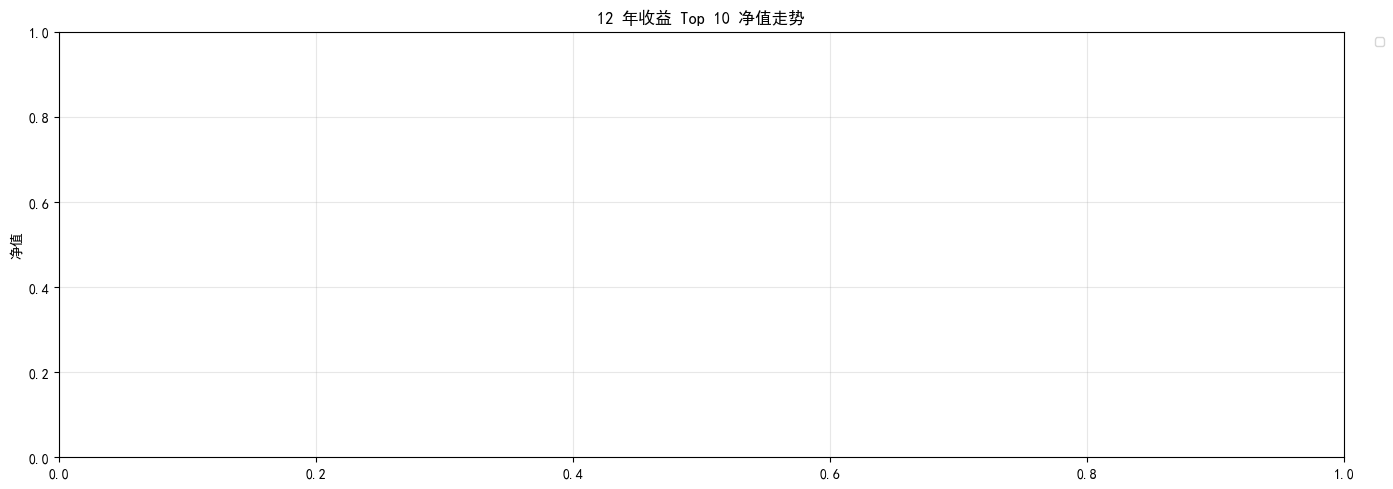

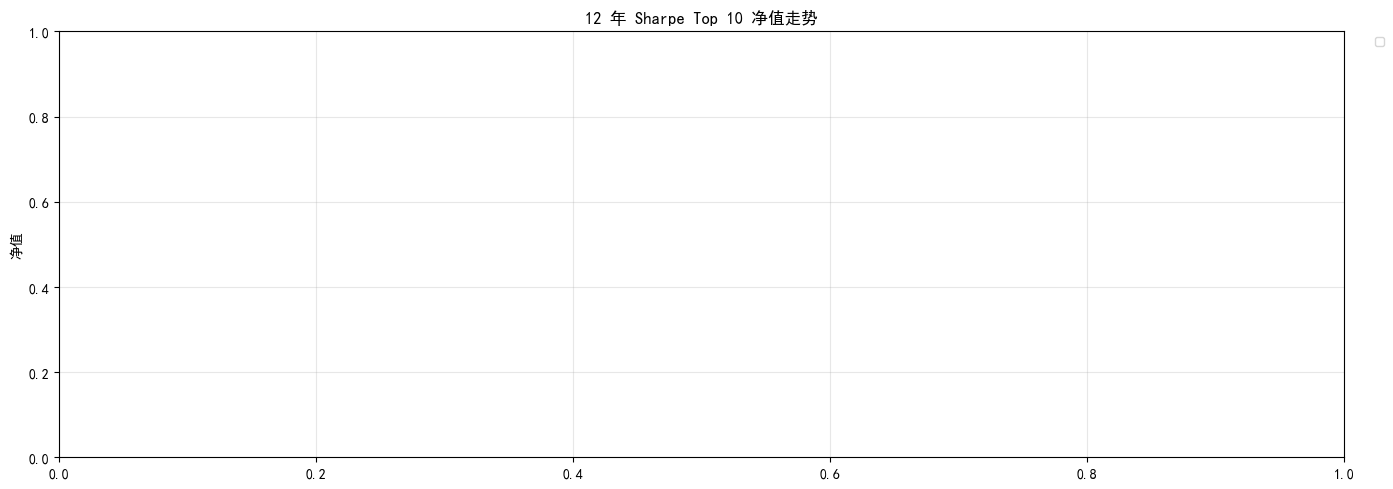

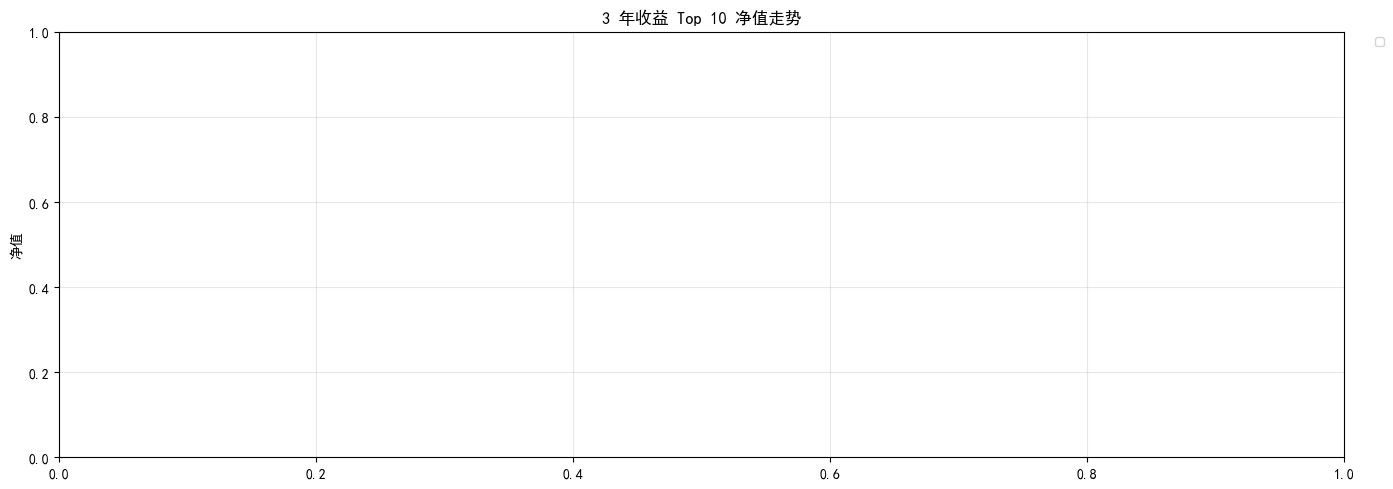

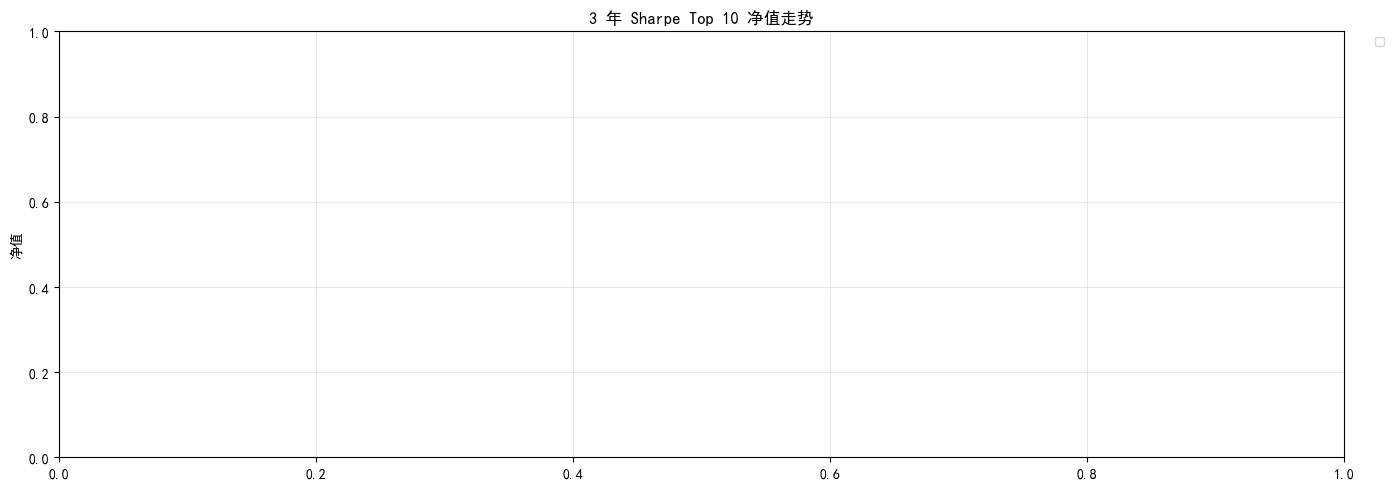

In [31]:
def _nav_key(row):
    """与 §4 回测中 label 格式一致，避免 float 精度导致 key 对不上。"""
    n = int(row['n'])
    r2 = round(float(row['R2_threshold']), 4)
    rebal = int(row['rebal_period'])
    top_k = int(row['top_k'])
    return f"n={n}_R2={r2}_rebal={rebal}_topk={top_k}"

import re

def _find_nav(cache, row):
    """先按 key 取，若无则按 (n,r2,rebal,top_k) 在 cache 的 key 里匹配。"""
    key = _nav_key(row)
    if key in cache:
        return cache[key]
    n, r2, rebal, top_k = int(row['n']), round(float(row['R2_threshold']), 4), int(row['rebal_period']), int(row['top_k'])
    for k in cache:
        if f"n={n}_" in k and f"_rebal={rebal}_" in k and f"_topk={top_k}" in k:
            m = re.search(r'R2=([\d.]+)', k)
            if m and abs(float(m.group(1)) - r2) < 1e-5:
                return cache[k]
    return None

# 1) 12 年收益 Top 10 走势
top10_ret_12y = result_df.nlargest(10, 'total_ret_12y')
fig, ax = plt.subplots(figsize=(14, 5))
for _, row in top10_ret_12y.iterrows():
    nav = _find_nav(nav_cache, row)
    if nav is not None:
        nav.plot(ax=ax, label=f"n={int(row['n'])} R²≥{row['R2_threshold']} T={int(row['rebal_period'])} k={int(row['top_k'])}", alpha=0.8)
ax.set_title('12 年收益 Top 10 净值走势')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.set_ylabel('净值')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2) 12 年 Sharpe Top 10 走势
top10_sharpe_12y = result_df.nlargest(10, 'sharpe_12y')
fig, ax = plt.subplots(figsize=(14, 5))
for _, row in top10_sharpe_12y.iterrows():
    nav = _find_nav(nav_cache, row)
    if nav is not None:
        nav.plot(ax=ax, label=f"n={int(row['n'])} R²≥{row['R2_threshold']} T={int(row['rebal_period'])} k={int(row['top_k'])}", alpha=0.8)
ax.set_title('12 年 Sharpe Top 10 净值走势')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.set_ylabel('净值')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3) 3 年收益 Top 10 走势
top10_ret_3y = result_df.nlargest(10, 'total_ret_3y')
fig, ax = plt.subplots(figsize=(14, 5))
for _, row in top10_ret_3y.iterrows():
    nav = _find_nav(nav_cache_3y, row)
    if nav is not None:
        nav.plot(ax=ax, label=f"n={int(row['n'])} R²≥{row['R2_threshold']} T={int(row['rebal_period'])} k={int(row['top_k'])}", alpha=0.8)
ax.set_title('3 年收益 Top 10 净值走势')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.set_ylabel('净值')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4) 3 年 Sharpe Top 10 走势
top10_sharpe_3y = result_df.nlargest(10, 'sharpe_3y')
fig, ax = plt.subplots(figsize=(14, 5))
for _, row in top10_sharpe_3y.iterrows():
    nav = _find_nav(nav_cache_3y, row)
    if nav is not None:
        nav.plot(ax=ax, label=f"n={int(row['n'])} R²≥{row['R2_threshold']} T={int(row['rebal_period'])} k={int(row['top_k'])}", alpha=0.8)
ax.set_title('3 年 Sharpe Top 10 净值走势')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.set_ylabel('净值')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. 四组 Top10 年收益表
上述四组 Top10 的逐年收益（12 年组为 2014–2026 年，3 年组为对应近 3 年年份）。

In [32]:
def _fmt_pct(s):
    return s.map(lambda x: f'{x:.2%}' if pd.notna(x) else '-')

# 1) 12 年收益 Top 10 年收益表
print('【12 年收益 Top 10】年收益')
tbl = top10_ret_12y[['n', 'R2_threshold', 'rebal_period', 'top_k'] + year_cols].copy()
tbl[year_cols] = _fmt_pct(tbl[year_cols])
tbl.index = range(1, len(tbl) + 1)
tbl.index.name = '排名'
display(tbl)

# 2) 12 年 Sharpe Top 10 年收益表
print('\n【12 年 Sharpe Top 10】年收益')
tbl2 = top10_sharpe_12y[['n', 'R2_threshold', 'rebal_period', 'top_k'] + year_cols].copy()
tbl2[year_cols] = _fmt_pct(tbl2[year_cols])
tbl2.index = range(1, len(tbl2) + 1)
tbl2.index.name = '排名'
display(tbl2)

# 3) 3 年收益 Top 10 年收益表（3 年区间内的年份列）
y3_cols = [c for c in result_df.columns if str(c).startswith('y') and '_3y' in str(c)]
if y3_cols:
    print('\n【3 年收益 Top 10】年收益')
    tbl3 = top10_ret_3y[['n', 'R2_threshold', 'rebal_period', 'top_k'] + y3_cols].copy()
    tbl3[y3_cols] = _fmt_pct(tbl3[y3_cols])
    tbl3.columns = ['n', 'R2_threshold', 'rebal_period', 'top_k'] + [c.replace('_3y', '').replace('y', '') for c in y3_cols]
    tbl3.index = range(1, len(tbl3) + 1)
    tbl3.index.name = '排名'
    display(tbl3)
    print('\n【3 年 Sharpe Top 10】年收益')
    tbl4 = top10_sharpe_3y[['n', 'R2_threshold', 'rebal_period', 'top_k'] + y3_cols].copy()
    tbl4[y3_cols] = _fmt_pct(tbl4[y3_cols])
    tbl4.columns = ['n', 'R2_threshold', 'rebal_period', 'top_k'] + [c.replace('_3y', '').replace('y', '') for c in y3_cols]
    tbl4.index = range(1, len(tbl4) + 1)
    tbl4.index.name = '排名'
    display(tbl4)
else:
    print('\n3 年组无单独年份列，请查看 result_df 中 annualized_3y / total_ret_3y。')

【12 年收益 Top 10】年收益


,n,R2_threshold,rebal_period,top_k,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
排名,,,,,,,,,,,,,,,,,
1,30,0.3,30,1,398.88%,-38.08%,-25.96%,39.48%,-37.72%,26.91%,117.05%,36.13%,-32.01%,17.37%,41.71%,110.36%,6.09%
2,5,0.4,30,1,139.78%,-3.12%,7.52%,36.95%,-21.91%,42.17%,142.31%,31.99%,-5.05%,-7.74%,-6.57%,34.95%,29.53%
3,5,0.5,30,1,155.42%,-15.67%,4.56%,24.00%,-18.79%,40.85%,142.31%,31.99%,3.29%,-7.74%,-6.57%,34.95%,29.53%
4,5,0.3,30,1,136.94%,-3.12%,21.68%,18.77%,-20.40%,42.17%,142.31%,31.99%,-5.05%,-7.74%,-6.57%,34.95%,29.53%
5,10,0.8,15,1,162.51%,37.52%,8.02%,50.54%,-12.23%,27.04%,94.99%,-7.79%,-7.43%,-8.77%,1.92%,30.99%,6.12%
6,30,0.6,30,1,194.48%,-10.79%,-14.64%,30.88%,-18.11%,-7.97%,55.67%,27.98%,-21.01%,39.73%,26.41%,110.36%,6.09%
7,30,0.5,30,1,168.78%,-18.47%,-14.64%,39.48%,-21.83%,-3.07%,102.68%,36.13%,-32.01%,17.37%,41.71%,110.36%,6.09%
8,5,0.6,30,1,155.42%,-15.67%,2.12%,8.28%,-6.66%,36.82%,155.11%,31.99%,-6.07%,-23.52%,-6.59%,34.95%,29.53%
9,30,0.4,30,1,218.48%,-38.08%,-25.96%,39.48%,-27.24%,26.16%,117.05%,36.13%,-32.01%,17.37%,41.71%,110.36%,6.09%



【12 年 Sharpe Top 10】年收益


,n,R2_threshold,rebal_period,top_k,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
排名,,,,,,,,,,,,,,,,,
1,15,0.8,30,5,44.73%,44.97%,1.52%,16.73%,-17.09%,34.25%,66.81%,1.47%,-21.89%,13.74%,8.97%,56.59%,2.09%
2,10,0.8,15,1,162.51%,37.52%,8.02%,50.54%,-12.23%,27.04%,94.99%,-7.79%,-7.43%,-8.77%,1.92%,30.99%,6.12%
3,5,0.5,30,1,155.42%,-15.67%,4.56%,24.00%,-18.79%,40.85%,142.31%,31.99%,3.29%,-7.74%,-6.57%,34.95%,29.53%
4,5,0.4,30,1,139.78%,-3.12%,7.52%,36.95%,-21.91%,42.17%,142.31%,31.99%,-5.05%,-7.74%,-6.57%,34.95%,29.53%
5,5,0.3,30,1,136.94%,-3.12%,21.68%,18.77%,-20.40%,42.17%,142.31%,31.99%,-5.05%,-7.74%,-6.57%,34.95%,29.53%
6,15,0.9,30,3,36.84%,14.21%,3.78%,4.77%,-9.57%,32.86%,42.80%,6.73%,-4.50%,4.11%,5.64%,21.64%,3.64%
7,5,0.6,30,1,155.42%,-15.67%,2.12%,8.28%,-6.66%,36.82%,155.11%,31.99%,-6.07%,-23.52%,-6.59%,34.95%,29.53%
8,15,0.9,30,2,44.72%,17.22%,3.63%,5.75%,-12.93%,29.30%,55.15%,-2.34%,-8.70%,13.62%,3.25%,22.20%,4.05%
9,15,0.9,30,5,28.45%,7.56%,1.58%,2.84%,-6.21%,33.78%,30.34%,-0.49%,-0.28%,1.28%,5.40%,20.81%,8.00%



【3 年收益 Top 10】年收益


,n,R2_threshold,rebal_period,top_k,2023,2024,2025,2026
排名,,,,,,,,
1,20,0.6,30,1,47.07%,61.16%,20.68%,-2.15%
2,25,0.9,15,1,3.86%,21.79%,96.28%,7.52%
3,25,0.8,15,1,-17.33%,40.20%,65.07%,25.64%
4,30,0.9,5,1,4.89%,5.51%,67.27%,23.98%
5,3,0.8,20,1,22.77%,-15.36%,107.98%,0.18%
6,20,0.7,30,1,47.07%,41.19%,15.09%,-4.02%
7,20,0.5,30,1,47.07%,25.06%,24.06%,-2.15%
8,40,0.9,10,1,14.53%,-4.77%,57.36%,29.03%
9,30,0.8,10,3,-6.48%,14.64%,56.08%,28.81%



【3 年 Sharpe Top 10】年收益


,n,R2_threshold,rebal_period,top_k,2023,2024,2025,2026
排名,,,,,,,,
1,25,0.9,15,3,5.67%,11.10%,73.55%,3.21%
2,25,0.9,15,5,4.15%,7.36%,58.42%,5.09%
3,25,0.9,15,1,3.86%,21.79%,96.28%,7.52%
4,40,0.9,20,5,3.66%,12.00%,42.53%,10.31%
5,25,0.9,15,2,7.19%,12.22%,65.05%,1.12%
6,40,0.9,20,3,6.12%,5.12%,48.39%,15.88%
7,30,0.9,5,1,4.89%,5.51%,67.27%,23.98%
8,40,0.9,20,2,8.85%,-2.38%,58.94%,16.12%
9,40,0.9,10,2,11.25%,-1.89%,50.24%,22.97%


## 9. 最优参数调仓明细（自动取 Top1）

In [33]:
import json as _json
with open('etf_all.json') as _f:
    _etf_data = _json.load(_f)
etf_name_map = {item['symbol']: item['name'] for item in _etf_data['data']['list']}

_best = result_df.nlargest(1, 'annualized_12y').iloc[0]
BEST_N = int(_best['n'])
BEST_R2 = _best['R2_threshold']
BEST_REBAL = int(_best['rebal_period'])
BEST_TOPK = int(_best['top_k'])
print(f'从全量回测 Top1 提取最优参数: n={BEST_N}, R²≥{BEST_R2}, rebal={BEST_REBAL}, top_k={BEST_TOPK}')

slope, r2 = linreg_cache[BEST_N]
start_idx = BEST_N + 5
dates = daily_ret.index[start_idx:]
rebal_indices = list(range(0, len(dates), BEST_REBAL))

trades = []
cum = 1.0
prev_selected = []

for i, idx_pos in enumerate(rebal_indices):
    date = dates[idx_pos]
    s = slope.loc[date].dropna()
    r = r2.loc[date].dropna()
    common = s.index.intersection(r.index)
    s, r = s[common], r[common]

    candidates = s[r >= BEST_R2].sort_values(ascending=False)
    selected = candidates.head(BEST_TOPK).index.tolist() if len(candidates) >= 1 else []

    # T日信号 → T+1日执行
    exec_idx = idx_pos + 1
    if exec_idx >= len(dates):
        break

    # 下一个信号日 → 下一个执行日
    next_signal_idx = rebal_indices[i + 1] if i + 1 < len(rebal_indices) else len(dates) - 1
    next_exec_idx = next_signal_idx + 1

    signal_date = dates[idx_pos]
    exec_date = dates[exec_idx]

    # 手续费（持仓变化才收）
    changed = sorted(selected) != sorted(prev_selected)
    trade_cost = 0.0
    if changed:
        if prev_selected:
            trade_cost += COMMISSION
        if selected:
            trade_cost += COMMISSION
        cum *= (1 - trade_cost)

    if selected:
        # 每只标的：买入价 = exec日 open*(1+slip)
        buy_prices = {}
        for sym in selected:
            op = panel_open.loc[exec_date, sym] if (exec_date in panel_open.index and sym in panel_open.columns) else panel.loc[exec_date, sym]
            buy_prices[sym] = op * (1 + SLIPPAGE)

        # 卖出价 = 下个执行日 open*(1-slip)，最后一期取最后收盘价
        sell_prices = {}
        if next_exec_idx < len(dates):
            sell_date = dates[next_exec_idx]
            for sym in selected:
                op = panel_open.loc[sell_date, sym] if (sell_date in panel_open.index and sym in panel_open.columns) else panel.loc[sell_date, sym]
                sell_prices[sym] = op * (1 - SLIPPAGE)
        else:
            sell_date = dates[-1]
            for sym in selected:
                sell_prices[sym] = panel.loc[sell_date, sym]

        # 收益 = 各标的 (卖出价/买入价 - 1) 的均值
        per_stock_rets = [(sell_prices[sym] / buy_prices[sym] - 1) for sym in selected]
        period_ret = np.mean(per_stock_rets)
        cum *= (1 + period_ret)

        buy_str = ','.join(f'{buy_prices[s]:.4f}' for s in selected)
        sell_str = ','.join(f'{sell_prices[s]:.4f}' for s in selected)
    else:
        period_ret = 0.0
        sell_date = dates[min(next_signal_idx, len(dates) - 1)]
        buy_str = '-'
        sell_str = '-'

    prev_selected = selected

    trades.append({
        '标的': ','.join(selected) if selected else '空仓',
        '名称': ','.join(etf_name_map.get(s, '-') for s in selected) if selected else '-',
        '信号日(T)': signal_date.strftime('%Y-%m-%d'),
        '执行日(T+1)': exec_date.strftime('%Y-%m-%d'),
        '买入价(open×1.001)': buy_str,
        '卖出日': sell_date.strftime('%Y-%m-%d'),
        '卖出价(open×0.999)': sell_str,
        '收益(卖/买-1)': f'{period_ret:.2%}',
        '手续费': f'{trade_cost:.4%}',
        '总净值': round(cum, 4),
    })

trade_df = pd.DataFrame(trades)
trade_df.to_csv('trade_detail.csv', index=False, encoding='utf-8-sig')
print(f'共 {len(trade_df)} 次调仓，已导出 trade_detail.csv')
display(trade_df)

从全量回测 Top1 提取最优参数: n=30, R²≥0.3, rebal=30, top_k=1
共 98 次调仓，已导出 trade_detail.csv


,标的,名称,信号日(T),执行日(T+1),买入价(open×1.001),卖出日,卖出价(open×0.999),收益(卖/买-1),手续费,总净值
0,SH510880,红利ETF华泰柏瑞,2014-02-27,2014-02-28,0.2693,2014-04-14,0.3307,22.80%,0.0060%,1.2280
1,SH510230,金融ETF,2014-04-11,2014-04-14,0.3493,2014-05-28,0.3157,-9.64%,0.0120%,1.1095
2,SH513500,标普500ETF博时,2014-05-27,2014-05-28,0.5315,2014-07-10,0.5475,3.00%,0.0120%,1.1426
3,SH510880,红利ETF华泰柏瑞,2014-07-09,2014-07-10,0.2913,2014-08-21,0.4675,60.50%,0.0120%,1.8337
4,SH510880,红利ETF华泰柏瑞,2014-08-20,2014-08-21,0.4685,2014-10-10,0.5564,18.78%,0.0000%,2.1780
...,...,...,...,...,...,...,...,...,...,...
93,SH515880,通信ETF,2025-08-14,2025-08-15,0.6386,2025-09-26,0.9151,43.29%,0.0120%,14.4156
94,SZ159755,电池ETF,2025-09-25,2025-09-26,1.0320,2025-11-17,1.1179,8.32%,0.0120%,15.6129
95,SH513310,中韩半导体ETF,2025-11-14,2025-11-17,2.6026,2025-12-29,2.5624,-1.54%,0.0120%,15.3701
96,SZ159206,卫星ETF,2025-12-26,2025-12-29,1.5596,2026-02-11,1.8482,18.50%,0.0120%,18.2122


## 10. 当前应持仓标的（使用 Top1 最优参数）

In [34]:
latest_date = panel.index[-1]
s_now = slope.loc[latest_date].dropna()
r_now = r2.loc[latest_date].dropna()
common = s_now.index.intersection(r_now.index)
s_now, r_now = s_now[common], r_now[common]

candidates = s_now[r_now >= BEST_R2].sort_values(ascending=False)

print(f'策略参数: n={BEST_N}, R²≥{BEST_R2}, rebal={BEST_REBAL}, top_k={BEST_TOPK}')
print(f'信号日期: {latest_date.strftime("%Y-%m-%d")}')
print()

if len(candidates) >= 1:
    pick = candidates.head(BEST_TOPK)
    print('当前应持仓标的:')
    for sym, slp in pick.items():
        r2_val = r_now[sym]
        price = panel.loc[latest_date, sym]
        name = etf_name_map.get(sym, '')
        print(f'  {sym} {name}  斜率={slp:.6f}  R²={r2_val:.4f}  最新价={price:.4f}')
else:
    print('当前无标的通过筛选 → 空仓')

print()
print(f'所有通过 R²≥{BEST_R2} 筛选的候选标的 (共 {len(candidates)} 只):')
cand_df = pd.DataFrame({
    '标的': candidates.index,
    '名称': [etf_name_map.get(s, '') for s in candidates.index],
    '斜率': candidates.values,
    'R²': [r_now[s] for s in candidates.index],
    '最新价': [panel.loc[latest_date, s] for s in candidates.index],
}).reset_index(drop=True)
display(cand_df.head(20))

策略参数: n=30, R²≥0.3, rebal=30, top_k=1
信号日期: 2026-03-13

当前应持仓标的:
  SZ159309 油气ETF汇添富  斜率=0.010028  R²=0.7391  最新价=1.6200

所有通过 R²≥0.3 筛选的候选标的 (共 115 只):


,标的,名称,斜率,R²,最新价
0,SZ159309,油气ETF汇添富,0.010028,0.739065,1.620
1,SH561360,石油ETF,0.008242,0.710838,1.657
2,SH513310,中韩半导体ETF,0.007769,0.648575,4.030
3,SZ159326,电网设备ETF,0.007500,0.868051,2.060
4,SZ159930,能源ETF,0.007313,0.811523,1.844
5,SH561380,电网ETF,0.006900,0.850938,2.222
6,SH515220,煤炭ETF,0.006782,0.857779,1.339
7,SZ159663,机床ETF,0.005640,0.689844,1.926
8,SZ159667,工业母机ETF,0.005585,0.693890,1.945
9,SZ159611,电力ETF,0.005046,0.733518,1.192
